In [3]:

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Load dataset
data = fetch_california_housing()
# Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target
print(df.head())



   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


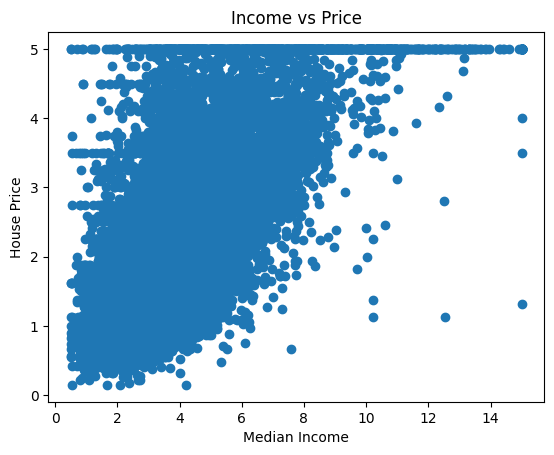

In [5]:

plt.scatter(df['MedInc'], df['Price'])
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Income vs Price")
plt.show()

In [6]:
# x = np.array([1000, 1500, 2000]).reshape(-1,1) # reshape required for sklearn
x = df['MedInc'].values.reshape(-1, 1)  # Using Median Income as feature
# print(x)
y = df['Price']
# y = np.array([2, 4, 5, 4, 5])

model = LinearRegression()
model.fit(x, y)
# Get coefficients
m = model.coef_[0]
c = model.intercept_

print("Slope (m):", m)
print("Intercept (c):", c)


Slope (m): 0.41793849201896294
Intercept (c): 0.4508557670326787


In [7]:
# Prediction
pred = model.predict([[5]])  # income = 5
print("Predicted price:", pred[0])

Predicted price: 2.540548227127493


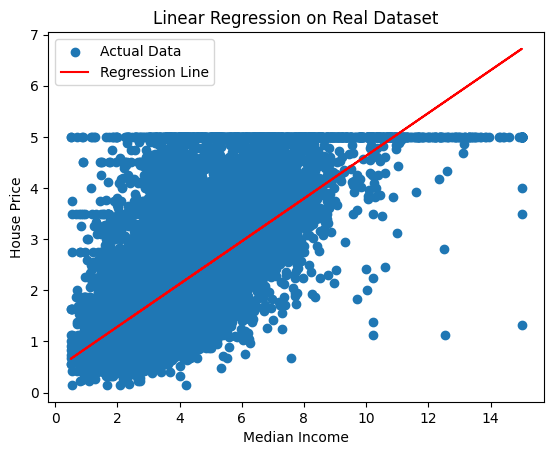

In [8]:
# Visualization
# Step 6: Visualization (IMPORTANT)

plt.scatter(x, y, label="Actual Data")
plt.plot(x, model.predict(x), color='red', label="Regression Line")

plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Linear Regression on Real Dataset")
plt.legend()
plt.show()

In [9]:
# Step 7: Evaluate Model (Very Important)

from sklearn.metrics import r2_score

y_pred = model.predict(x)

print("R2 Score:", f"{r2_score(y, y_pred):.4f}")

R2 Score: 0.4734


In [16]:
# R2 Score: 0.4734  Means that 47.34% of the variance in house prices can be explained by median income alone.
# solution to increase R2 score is to add more features like 'AveRooms', 'AveBedrms', 'Population', etc.

# Nedd to add more features to improve the model and increase R2 score.

x = df.drop('Price', axis=1)  # Using multiple features
model.fit(x, y)
y=df['Price']

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

y_pred = model.predict(x)

print("R2 Score with multiple features:", f"{r2_score(y, y_pred):.4f}")


sample = [[
    5.0,     # MedInc (income)
    20,      # HouseAge
    6,       # Avg Rooms
    1,       # Avg Bedrooms
    1000,    # Population
    3,       # Avg Occupancy
    37,      # Latitude
    -122     # Longitude
]]


print("Predicted price for sample input:", model.predict(sample))


Coefficients: [ 4.36693293e-01  9.43577803e-03 -1.07322041e-01  6.45065694e-01
 -3.97638942e-06 -3.78654265e-03 -4.21314378e-01 -4.34513755e-01]
Intercept: -36.94192020718454
R2 Score with multiple features: 0.6062
Predicted price for sample input: [2.83810535]


d:\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


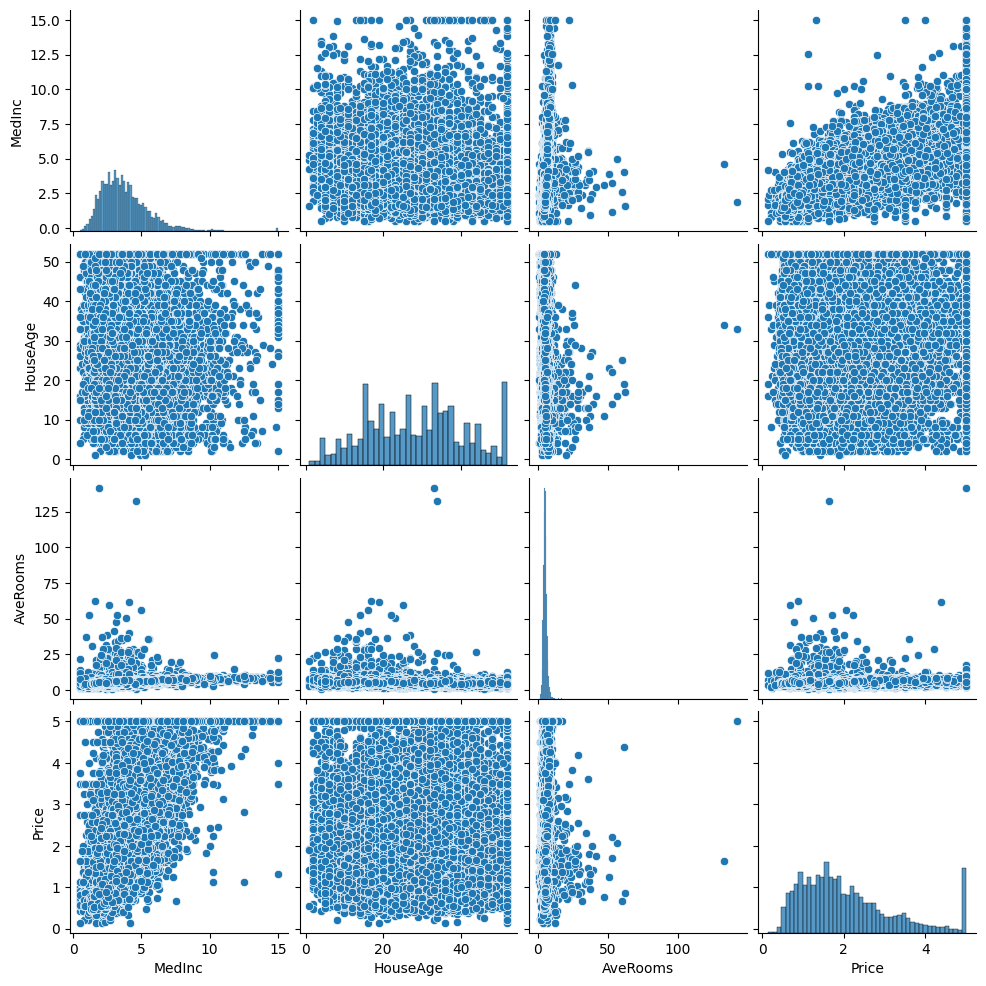

In [17]:
import seaborn as sns

sns.pairplot(df[['MedInc', 'HouseAge', 'AveRooms', 'Price']])